In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib import colormaps 
from scipy.integrate import solve_ivp
import timeit
from scipy.sparse import csr_array,block_array,eye,coo_array
import subprocess
import struct
from multiprocess import Pool
from IPython.display import Video,display
import networkx as nx
colors=plt.rcParams['axes.prop_cycle'].by_key()['color']

loadstr=''
try:
    loadstr='module load %s &&'%(subprocess.check_output("module avail | grep cuda/", shell=True, text=True).split()[-1])
except:
    pass

Define coupling parameters for CGLE

$$
\frac{\partial A}{\partial t} = A + (1+ib)\nabla^2 A - (1-ic)|A|^2 A,
$$

which we separate into real and imaginary parts $A=X+iY$ with


$$
\frac{\partial X}{\partial t} = X + \nabla^2 X - b \nabla^2 Y - (X^2+Y^2)X - c (X^2+Y^2)Y, 
$$

$$
\frac{\partial Y}{\partial t} = Y + \nabla^2 Y + b \nabla^2 X - (X^2+Y^2)Y + c (X^2+Y^2)X.
$$

We can find the indices for the coupling terms with the help function with no filebase. We illustrate first in two spatial dimensions and later in one and three spatial dimensions.

In [2]:
Ns=[256,256]
Ls=[100.0,100.0]
T=10
dt=0.1
cmd='%s ./rdcu -N %i,%i -L %f,%f -n 2 -h'%(loadstr, Ns[0],Ns[1],Ls[0],Ls[1])
print(cmd)
os.system(cmd)

module load cuda/12.9.1-binary && ./rdcu -N 256,256 -L 100.000000,100.000000 -n 2 -h
usage:	rdcu [-hvSFR] [-n NFIELDS] [-N NUMS] [-L LENGTHS]
	[-c COUPLING] [-A AMPLITUDE] [-t TIME] [-d DT] [-s SEED] 
	[-D DENSITY] [-g GPU] [-r RTOL] [-a ATOL]  FILEBASE 

-h for help. Call with -n and -N to see Y indices. 
-v for verbose output, including progress 
-S for stiff system. Use the BDF method with finite differences instead of RK45 pseudospectral method. 
-F for fixed timestep 
-R to reload final state from FILEBASEfs.dat if possible
NFIELDS is the number of fields. Default 1
NUMS is number of grid points in each dimension (up to three), separated by commas (no spaces). Default 128
LENGTHS is domain length in each dimension (up to three), separated by commas (no spaces). Default 1.0
COUPLING is a list of coupling terms, separated by commas (no spaces). Default empty
	The first value is the term coefficent. 
	The second value is an integer specifying the field that the term appears in. 
	The

0

In [3]:
filebase='data/2dcgle'

b=2.0 
c=0.8
couplings=['1.0,0,0,1', '1.0,0,6,1', '1.0,0,12,1', '-%f,0,7,1'%(b), \
           '-%f,0,13,1'%(b), '-1.0,0,0,3', '-1.0,0,0,1,1,2', '1.0,1,1,1', \
           '1.0,1,7,1', '1.0,1,13,1', '%f,1,6,1'%(b),'%f,1,12,1'%(b), \
           '-1.0,1,0,2,1,1', '-1.0,1,1,3', '%f,1,0,3'%(c), '%f,1,0,1,1,2'%(c), \
           '-%f,0,0,2,1,1'%(c),'-%f,0,1,3'%(c)]

file=open('%scoupling.dat'%(filebase),'w')
for line in couplings:
    print(line,file=file)
file.close()

Explicit runge-kutta pseudospectral on the gpu

In [4]:
cmd='%s ./rdcu -t %f -d %f -N %i,%i -L %f,%f -n 2 -v -D1 %s'%(loadstr,T,dt,Ns[0],Ns[1],Ls[0],Ls[1],filebase)
print(cmd)
os.system(cmd)

module load cuda/12.9.1-binary && ./rdcu -t 10.000000 -d 0.100000 -N 256,256 -L 100.000000,100.000000 -n 2 -v -D1 data/2dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Using random initial conditions
1.000	9.746e+00	-9.025e-04	0.010712	924	
runtime: 9.749201


0

runtime: 9.749201



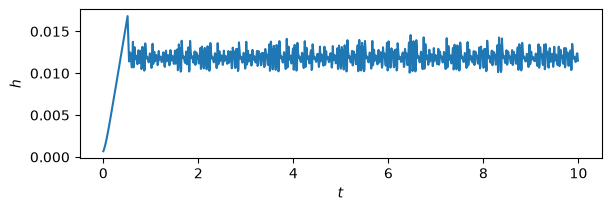

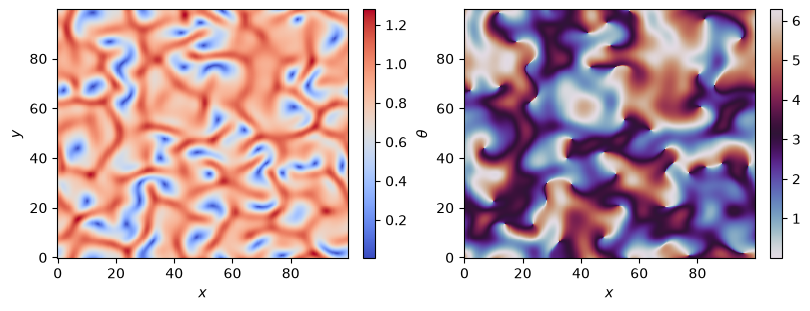

In [5]:
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
U0=ys[0].reshape(-1)
ts=np.fromfile(filebase+'times.dat')

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi
plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()


implicit BDF with finite differences on gpu with the same initial condition. Note the first few timesteps are small before the BDF stabilizes.

In [6]:
cmd='%s ./rdcu -t %f -d %f -N %i,%i -L %f,%f -n 2 -v -S -D1 %s'%(loadstr,T,dt,Ns[0],Ns[1],Ls[0],Ls[1],filebase)

print(cmd)
os.system(cmd)

module load cuda/12.9.1-binary && ./rdcu -t 10.000000 -d 0.100000 -N 256,256 -L 100.000000,100.000000 -n 2 -v -S -D1 data/2dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Using random initial conditions
1.002	5.636e+00	-1.258e-02	0.035750	629	
runtime: 5.845498


0

runtime: 5.845498



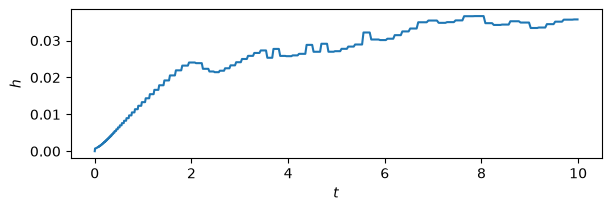

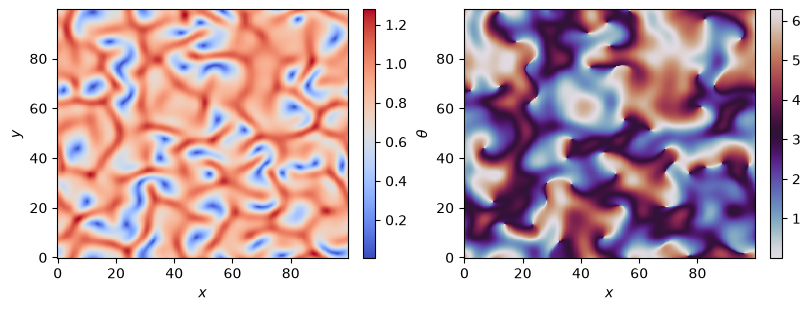

In [7]:
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()


Explicit runge-kutta pseudospectral on the cpu. The GPU results are almost identical and much faster, and performance benefits increase with increasing Ns.

In [9]:
def lap(y,Ls,Ns):
    yfft=np.fft.fftn(y)
    ret=-np.fft.fftfreq(Ns[0],Ls[0]/(2*np.pi*Ns[0])).reshape((Ns[0],1))**2*yfft
    ret=ret-np.fft.fftfreq(Ns[1],Ls[1]/(2*np.pi*Ns[1])).reshape((1,Ns[1]))**2*yfft
    return np.fft.ifftn(ret)

def cgle(t, U, b, c, Ls, Ns):
    N=Ns[0]*Ns[1]
    X=U[:N].reshape(Ns)
    Y=U[N:].reshape(Ns)
    A=X+1j*Y
    lapA=lap(A,Ls,Ns)
    lapX=np.real(lapA)
    lapY=np.imag(lapA)
    retX=X+lapX-b*lapY-(X**2+Y**2)*(X+c*Y)
    retY=Y+lapY+b*lapX-(X**2+Y**2)*(Y-c*X)
    ret=np.zeros(U.shape)
    ret[:N]=retX.reshape(-1)
    ret[N:]=retY.reshape(-1)
    return ret

start=timeit.default_timer()
sol1=solve_ivp(cgle,[0,T],U0,args=[b,c,Ls,Ns],method='RK45',rtol=1E-8,atol=1E-8,first_step=0.03)
stop=timeit.default_timer()
print("runtime: ", stop-start, flush=True)

ys=sol1.y.reshape([2]+Ns+[-1]).transpose(3,0,1,2)
ts=sol1.t

runtime:  17.3481993440073


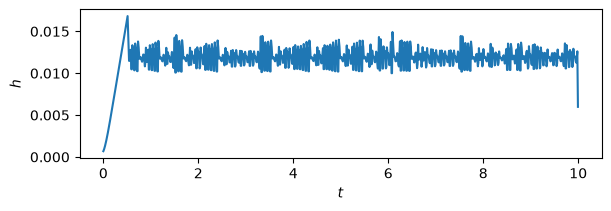

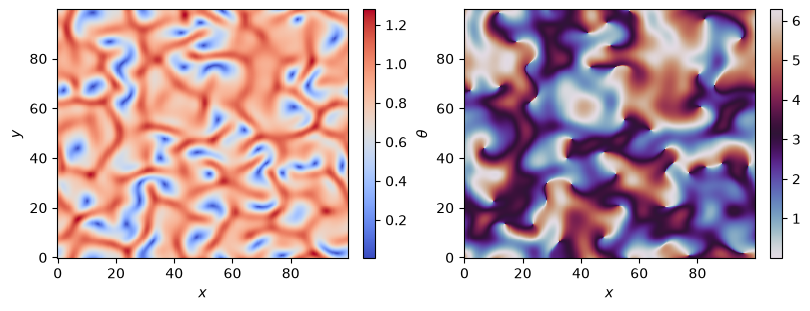

In [11]:
ys=sol1.y.reshape([2]+Ns+[-1]).transpose(3,0,1,2)
ts=sol1.t

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()


implicit BDF with finite differences on cpu. The GPU results are again almost identical and are comparatively even faster. The sparse LU solver from scipy performs poorly compared to cudss and scales very poorly with increasing Ns.

In [10]:
def lap(y,Ls,Ns):
    return (np.roll(y,1,axis=0)+np.roll(y,-1,axis=0)-2*y)/(Ls[0]/Ns[0])**2+(np.roll(y,1,axis=1)+np.roll(y,-1,axis=1)-2*y)/(Ls[1]/Ns[1])**2

def cgle(t, U, b, c, Ls, Ns, I, JI):
    N=Ns[0]*Ns[1]
    X=U[:N].reshape(Ns)
    Y=U[N:].reshape(Ns)
    A=X+1j*Y
    lapA=lap(A,Ls,Ns)
    lapX=np.real(lapA)
    lapY=np.imag(lapA)
    retX=X+lapX-b*lapY-(X**2+Y**2)*(X+c*Y)
    retY=Y+lapY+b*lapX-(X**2+Y**2)*(Y-c*X)
    ret=np.zeros(U.shape)
    ret[:N]=retX.reshape(-1)
    ret[N:]=retY.reshape(-1)
    return ret

def jac(t, U, b, c, Ls, Ns, I, JI):
    N=Ns[0]*Ns[1]
    X=U[:N]
    Y=U[N:]
#     retX=X+lapX-b*lapY-(X**2+Y**2)*(X+c*Y)
    retXX=I+JI-(2*X*I)*(X+c*Y)-(X**2+Y**2)*I
    retXY=-b*JI-(2*Y*I)*(X+c*Y)-(X**2+Y**2)*I*c
#     retY=Y+lapY+b*lapX-(X**2+Y**2)*(Y-c*X)
    retYX=b*JI-(2*X*I)*(Y-c*X)+(X**2+Y**2)*I*c
    retYY=I+JI-(2*Y*I)*(Y-c*X)-(X**2+Y**2)*I
    return block_array([[retXX,retYX],[retXY, retYY]]).T

N=Ns[0]*Ns[1]
I=csr_array(eye(N))
coords=I.reshape(Ns+Ns).coords
data=I.reshape(Ns+Ns).data
Ip0=coo_array((data,(coords[0],coords[1],np.roll(coords[2],Ns[0]),coords[3])),Ns+Ns).reshape(N,N)
Ip1=coo_array((data,(coords[0],coords[1],coords[2],np.roll(coords[3],1))),Ns+Ns).reshape(N,N)
Im0=coo_array((data,(coords[0],coords[1],np.roll(coords[2],-Ns[0]),coords[3])),Ns+Ns).reshape(N,N)
Im1=coo_array((data,(coords[0],coords[1],coords[2],np.roll(coords[3],-1))),Ns+Ns).reshape(N,N)
JI=(Ip0+Im0-2*I)/(Ls[0]/Ns[0])**2+(Ip1+Im1-2*I)/(Ls[1]/Ns[1])**2

start=timeit.default_timer()
sol2=solve_ivp(cgle,[0,T],U0,args=[b,c,Ls,Ns,I,JI],method='BDF',jac=jac,rtol=1E-8,atol=1E-8)
stop=timeit.default_timer()
print("runtime: ", stop-start, flush=True)

runtime:  559.0860580130247


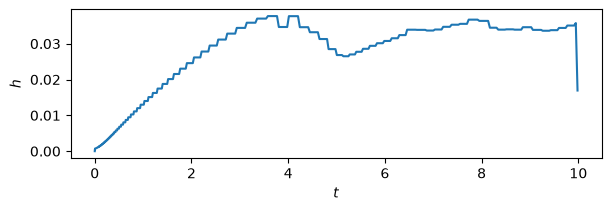

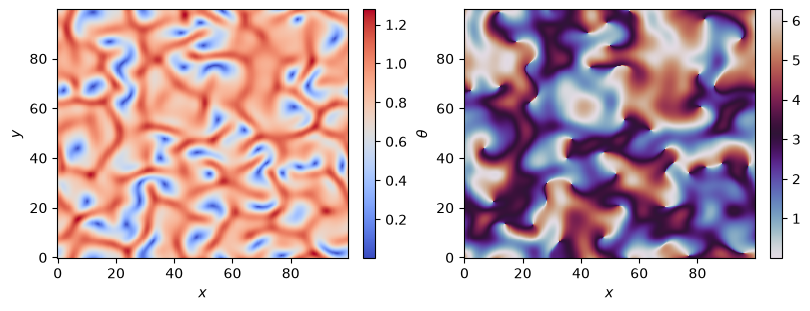

In [11]:
ys=sol2.y.reshape([2]+Ns+[-1]).transpose(3,0,1,2)
ts=sol2.t

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()


Note that BDF takes larger steps that RK45. As the number of mesh points Ns increases, the system gets stiffer and RK45 takes increasingly smaller steps while BDF does not. The sparse LU scales well enough that BDF outperforms RK45 for large Ns.  Even though the pseudospectral discretization is generally superior to finite difference, BDF may be preferred for fine spatial resolution. Illustrate with a large system size.

In [16]:
Ns=[1024,1024]
Ls=[100.0,100.0]

cmd='%s ./rdcu -t %f -d %f -N %i,%i -L %f,%f -n 2 -v -D1 %s'%(loadstr,T,dt,Ns[0],Ns[1],Ls[0],Ls[1],filebase)
print(cmd)
os.system(cmd)

module load cuda/12.9.1-binary && ./rdcu -t 10.000000 -d 0.100000 -N 1024,1024 -L 100.000000,100.000000 -n 2 -v -D1 data/2dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Using random initial conditions
1.000	1.446e+02	-7.833e-03	0.000829	13619	
runtime: 144.672992


0

runtime: 144.672992



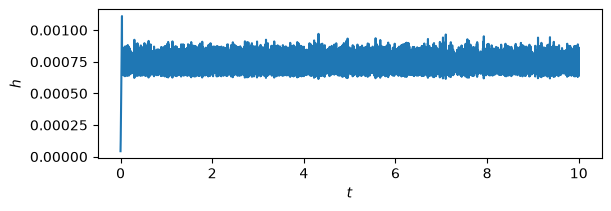

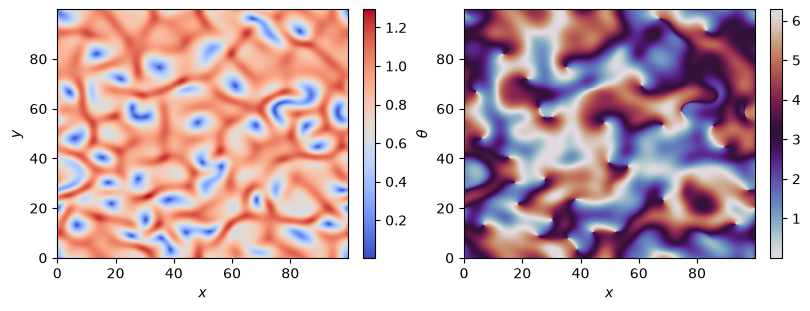

In [17]:
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()


In [18]:
Ns=[1024,1024]
Ls=[100.0,100.0]

cmd='%s ./rdcu -t %f -d %f -N %i,%i -L %f,%f -S -n 2 -v -D1 %s'%(loadstr,T,dt,Ns[0],Ns[1],Ls[0],Ls[1],filebase)
print(cmd)
os.system(cmd)

module load cuda/12.9.1-binary && ./rdcu -t 10.000000 -d 0.100000 -N 1024,1024 -L 100.000000,100.000000 -S -n 2 -v -D1 data/2dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Using random initial conditions
1.003	5.049e+01	-1.324e-01	0.035411	779	
runtime: 50.663140


0

runtime: 50.663140



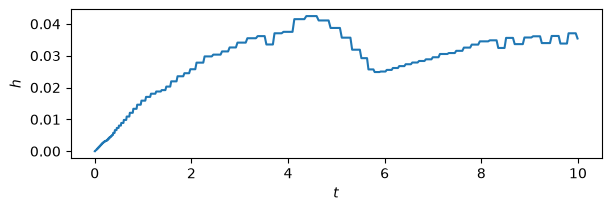

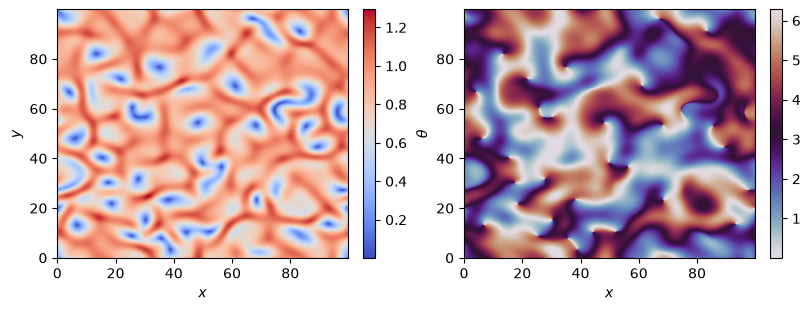

In [19]:
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()

For both integration methods, we can reload saved final states in FILEBASEfs.dat with the -R flag to continue

In [20]:
cmd='%s./rdcu -t %f -d %f -N %i,%i -L %f,%f -R -S -n 2 -v -D1 %s'%(loadstr,2*T,dt,Ns[0],Ns[1],Ls[0],Ls[1],filebase)
print(cmd)
os.system(cmd)

module load cuda/12.9.1-binary &&./rdcu -t 20.000000 -d 0.100000 -N 1024,1024 -L 100.000000,100.000000 -R -S -n 2 -v -D1 data/2dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Reloading final conditions from file
Restarting at t=10.026377 with h=0.035411
1.002	3.790e+01	-8.594e-02	0.035654	273	
runtime: 38.131187


0

runtime: 38.131187



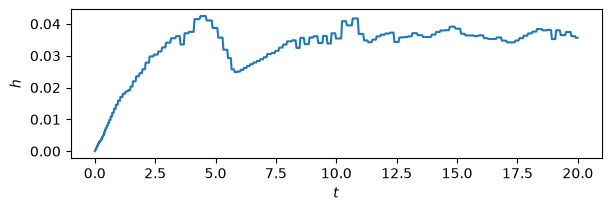

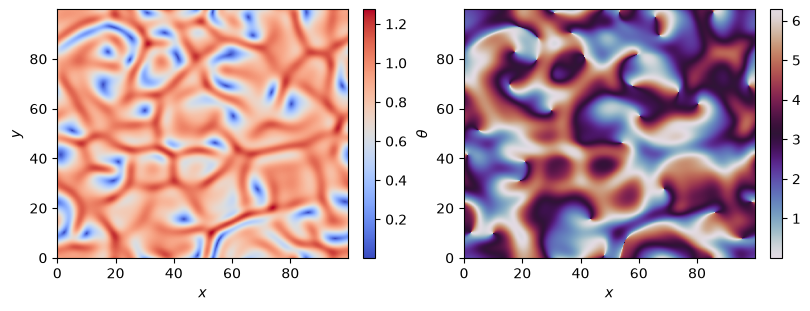

In [21]:
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()


1D CGLE. Change parameters for an intermittency example.

In [22]:
Ns=[8192]
N=Ns[0]
Ls=[200.0] 
T=100

filebase='data/1dcgle'

b=0.1
c=2.0
couplings=['1.0,0,0,1', '1.0,0,4,1', '-%f,0,5,1'%(b),  \
           '-1.0,0,0,3', '-1.0,0,0,1,1,2', '1.0,1,1,1', \
           '1.0,1,5,1', '%f,1,4,1'%(b), \
           '-1.0,1,0,2,1,1', '-1.0,1,1,3', '%f,1,0,3'%(c), '%f,1,0,1,1,2'%(c), \
           '-%f,0,0,2,1,1'%(c),'-%f,0,1,3'%(c)]

file=open('%scoupling.dat'%(filebase),'w')
for line in couplings:
    print(line,file=file)
file.close()

cmd='%s ./rdcu -t %f -d %f -N %i -L %f -n 2 -v -D1 -S %s'%(loadstr,T,dt,Ns[0],Ls[0],filebase)
print(cmd)
os.system(cmd)

module load cuda/12.9.1-binary && ./rdcu -t 100.000000 -d 0.100000 -N 8192 -L 200.000000 -n 2 -v -D1 -S data/1dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + -0.100(u1_00)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -2.000(u0)^2(u1)^1 + -2.000(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 0.100(u0_00)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 2.000(u0)^3 + 2.000(u0)^1(u1)^2 + 0
Using random initial conditions
1.000	7.899e+00	-9.638e-04	0.028828	3737	
runtime: 7.901359


0

runtime: 7.901359



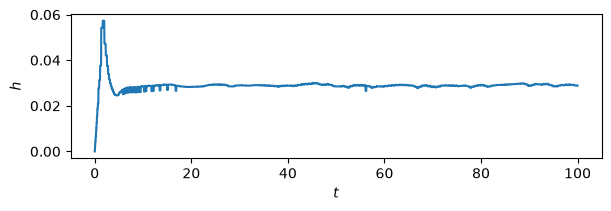

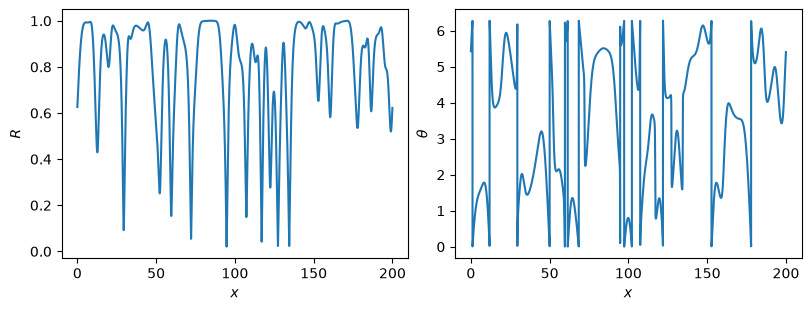

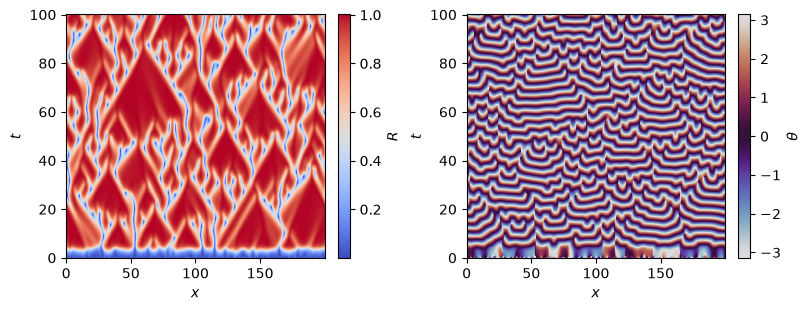

In [23]:
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.plot(np.arange(Ns[0])/Ns[0]*Ls[0], R)
ax.set_xlabel('$x$')
ax.set_ylabel('$R$')

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.plot(np.arange(Ns[0])/Ns[0]*Ls[0], R)
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')

plt.show()

fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[:,0]**2+ys[:,1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(ys.shape[0])*0.1, R,cmap='coolwarm')
plt.xlabel(r'$x$')
plt.ylabel(r'$t$')
plt.colorbar(label=r'$R$')

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[:,1],ys[:,0])

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(ys.shape[0])*0.1, R,cmap='twilight')
plt.xlabel(r'$x$')
plt.ylabel(r'$t$')
plt.colorbar(label=r'$\theta$')

plt.show()

3d CGLE. Change parameters for frozen vortices, and make a fancy animation with defect lines. Do fixed timesteps for T0 initial time units first to initialize a random state, then run for T time units. Animate all outputs after T1 later.

In [2]:
Ns=np.array([128,128,128])
Ls=[50.0,50.0,50.0]
b=0.5
c=2.0
filebase='data/3dcgle'
T0=0.1
dt0=1E-3

T=500
dt=0.1

T1=400
n0=int(T0/dt0)+int(T1/dt)
nt=int(T/dt)-int(T1/dt)

# Ns=[128,128,128]
# Ls=[200.0,200.0,200.0]
# b=0.0
# c=1.5
# filebase='data/3dcgle_2'
# T0=0.1
# dt0=1E-3

# T=1500
# dt=1.0

# T1=500
# n0=int(T0/dt0)+int(T1/dt)
# nt=int(T/dt)-int(T1/dt)

couplings=['1.0,0,0,1', '1.0,0,8,1', '1.0,0,16,1', '1.0,0,24,1', '-%f,0,9,1'%(b), \
           '-%f,0,17,1'%(b), '-%f,0,25,1'%(b), '-1.0,0,0,3', '-1.0,0,0,1,1,2', '1.0,1,1,1', \
           '1.0,1,9,1', '1.0,1,17,1', '1.0,1,25,1', '%f,1,8,1'%(b),'%f,1,16,1'%(b), '%f,1,24,1'%(b), \
           '-1.0,1,0,2,1,1', '-1.0,1,1,3', '%f,1,0,3'%(c), '%f,1,0,1,1,2'%(c), \
           '-%f,0,0,2,1,1'%(c),'-%f,0,1,3'%(c)]

file=open('%scoupling.dat'%(filebase),'w')
for line in couplings:
    print(line,file=file)
file.close()

In [5]:
cmd='%s ./rdcu -s 1 -t %f -d %f -N %i,%i,%i -L %f,%f,%f -n 2 -D1 -Fv %s'%(loadstr,T0,dt0,Ns[0],Ns[1],Ns[2],Ls[0],Ls[1],Ls[2],filebase)
print(cmd)
os.system(cmd)
cmd='%s ./rdcu -s 1 -t %f -d %f -N %i,%i,%i -L %f,%f,%f -n 2 -D1 -Rv  %s'%(loadstr,T,dt,Ns[0],Ns[1],Ns[2],Ls[0],Ls[1],Ls[2],filebase)
print(cmd)
os.system(cmd)

module load cuda/12.9.1-binary && ./rdcu -s 1 -t 0.100000 -d 0.001000 -N 128,128,128 -L 200.000000,200.000000,200.000000 -n 2 -D1 -Fv data/3dcgle_2
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + 1.000(u0_22)^1 + -0.000(u1_00)^1 + -0.000(u1_11)^1 + -0.000(u1_22)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -1.500(u0)^2(u1)^1 + -1.500(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 1.000(u1_22)^1 + 0.000(u0_00)^1 + 0.000(u0_11)^1 + 0.000(u0_22)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 1.500(u0)^3 + 1.500(u0)^1(u1)^2 + 0
Using random initial conditions
1.000	6.267e+01	-4.134e-14	0.001000	100	
runtime: 62.941466
module load cuda/12.9.1-binary && ./rdcu -s 1 -t 1500.000000 -d 1.000000 -N 128,128,128 -L 200.000000,200.000000,200.000000 -n 2 -D1 -Rv  data/3dcgle_2
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + 1.000(u0_22)^1 + -0.000(u1_00)^1 + -0.000(u1_11)^1 + -0.000(u1_22)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 

0

Plot the lines of defects by finding the connected components in the graph of neighboring cells with nonzero wilson loops on a face

In [3]:
def wloop(th, axis1=0, axis2=1):
    dth1=np.mod(np.roll(th,1,axis=axis1)-th+np.pi,2*np.pi)-np.pi
    dth2=np.mod(np.roll(np.roll(th,1,axis=axis1),1,axis=axis2)-np.roll(th,1,axis=axis1)+np.pi,2*np.pi)-np.pi
    dth3=np.mod(np.roll(th,1,axis=axis2)-np.roll(np.roll(th,1,axis=axis1),1,axis=axis2)+np.pi,2*np.pi)-np.pi
    dth4=np.mod(th-np.roll(th,1,axis=axis2)+np.pi,2*np.pi)-np.pi
    return np.round((dth1+dth2+dth3+dth4)/(2*np.pi))

    
def findlines(th):
    lines01=np.array(coo_array(wloop(th, axis1=0, axis2=1)).coords)
    lines12=np.array(coo_array(wloop(th, axis1=1, axis2=2)).coords)
    lines20=np.array(coo_array(wloop(th, axis1=2, axis2=0)).coords)
    
    lines=np.concatenate([lines01,lines12,lines20],axis=1)
    raveled=np.apply_along_axis(lambda row: np.ravel_multi_index(row,Ns), axis=0, arr=lines)
    arr=np.array(np.unravel_index(np.unique(raveled),shape=Ns))
    
    diffs=(arr[:,:,np.newaxis]-arr[:,np.newaxis,:])
    for axis in range(3):
        diffs[axis]=np.mod(diffs[axis]+Ns[axis]//2,Ns[axis])-Ns[axis]//2
    
    adj=np.linalg.norm(diffs,ord=np.inf,axis=0).astype(int)
    adj=np.where(adj<=1,adj,0)
    G=nx.from_numpy_array(adj)
    components=[component for component in nx.connected_components(G)]

    lines=[]
    for component in components:
        starts,ends=np.where(adj[list(component)]>0)
        starts=np.array(list(component))[starts]
        line=[]
        for j in range(len(starts)):
            l=np.linalg.norm(arr[:,starts[j]]-arr[:,ends[j]],ord=np.inf)
            segment=np.array([arr[:,starts[j]]*Ls/(Ns-1),arr[:,ends[j]]*Ls/(Ns-1)])
            line=line+[segment]
        lines=lines+[np.array(line)]
            
    return lines

def plotlines(lines, ax, cmap):
    cscale=np.max([len(line) for line in lines])
    coffset=np.min([len(line) for line in lines])
    for i in range(len(lines)):
        c=cmap((len(lines[i])-coffset)/(cscale-coffset))
        for line in lines[i]:
            if np.linalg.norm(line[0]-line[1],ord=np.inf)<np.min(Ls)/2:
                alpha=0.1*np.linalg.norm(([0,Ls[1],0]-line[0])/Ls,ord=np.inf)
                ax.plot(*line.T,lw=1.5, marker=None, c=c, alpha=alpha)
            else:
                if (line[0][0]==0 or line[0][1]==Ls[1] or line[0][2]==0) and not (line[1][0]==0 or line[1][1]==Ls[1] or line[1][2]==0):
                    ax.scatter(*line[0],s=10,color=c,alpha=0.25)
                if (line[0][0]==Ls[0] or line[0][1]==0 or line[0][2]==Ls[2]) and not (line[1][0]==Ls[0] or line[1][1]==0 or line[1][2]==Ls[2]):
                    ax.scatter(*line[0],s=10,color=c,alpha=1.0)
                if (line[1][0]==0 or line[1][1]==Ls[1] or line[1][2]==0) and not (line[0][0]==0 or line[0][1]==Ls[1] or line[0][2]==0):
                    ax.scatter(*line[1],s=10,color=c,alpha=0.25)
                if (line[1][0]==Ls[0] or line[1][1]==0 or line[1][2]==Ls[2]) and not (line[0][0]==Ls[0] or line[0][1]==0 or line[0][2]==Ls[2]):
                    ax.scatter(*line[1],s=10,color=c,alpha=1.0)
    
    ax.plot([Ls[0],Ls[0]],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[0,0],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[0,0],[0,0], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[0,0], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,0],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[Ls[1],Ls[1]],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[Ls[1],Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,0],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    
    ax.set_xlim(0,Ls[0])
    ax.set_ylim(0,Ls[1])
    ax.set_zlim(0,Ls[1])
    
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_zlabel('$z$')
    # ax.set_box_aspect(aspect=None, zoom=0.85) 
    

def plotfaces(R, ax, cmap):
    Rmax=np.max(R)
    Y,X=np.meshgrid(np.arange(Ns[0])/Ns[0]*Ls[0],np.arange(Ns[1])/Ns[1]*Ls[1])
    Z=Ls[2]*np.ones(X.shape)
    C=cmap(R[:,:,-1]/Rmax)
    ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)
    
    X,Z=np.meshgrid(np.arange(Ns[0])/Ns[0]*Ls[0],np.arange(Ns[2])/Ns[2]*Ls[2])
    Y=0*np.ones(X.shape)
    C=cmap(R[:,0,:].T/Rmax)
    ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)
    
    Z,Y=np.meshgrid(np.arange(Ns[1])/Ns[1]*Ls[1],np.arange(Ns[2])/Ns[2]*Ls[2])
    X=Ls[0]*np.ones(X.shape)
    C=cmap(R[-1,:,:]/Rmax)
    ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)
    
    ax.plot([Ls[0],Ls[0]],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[0,0],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[0,0],[0,0], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[0,0], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,0],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[Ls[1],Ls[1]],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[Ls[1],Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,0],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    
    ax.set_xlim(0,Ls[0])
    ax.set_ylim(0,Ls[1])
    ax.set_zlim(0,Ls[2])
    
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_zlabel('$z$')
    

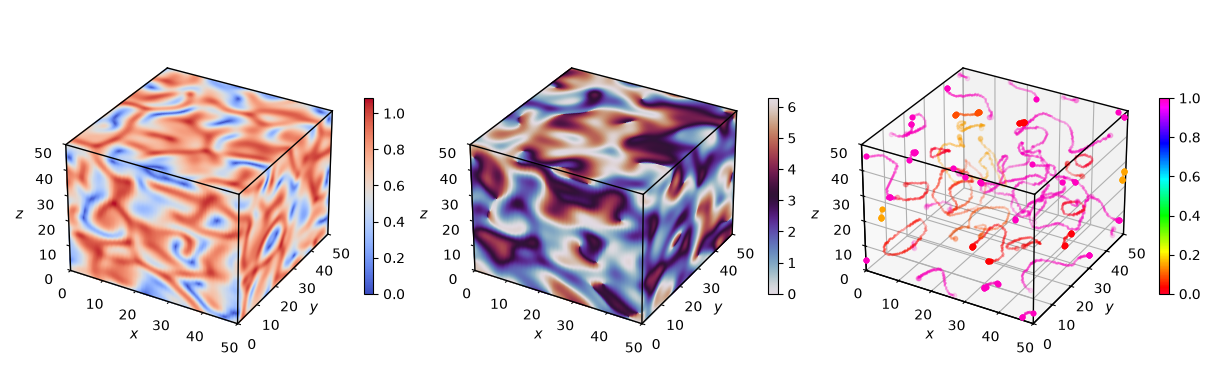

18.218899818952195


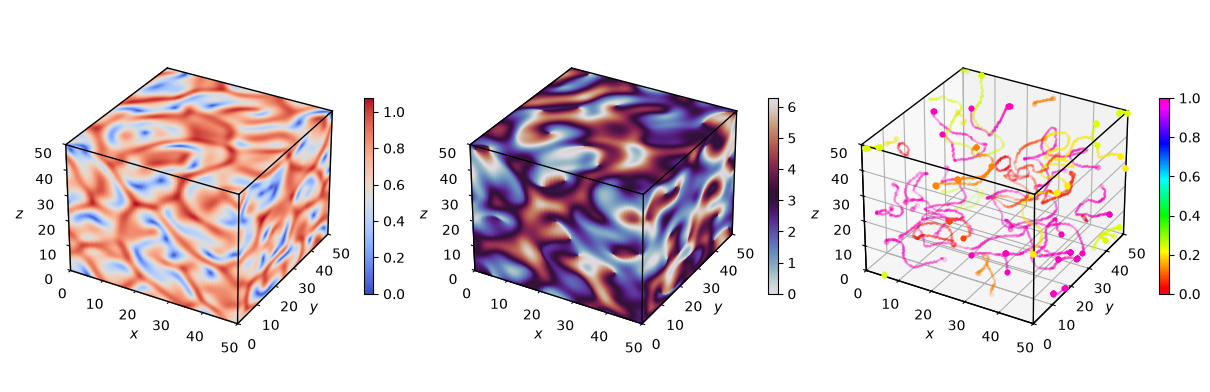

15.573612323962152


In [4]:
def makeplot(n,show=False,save=True):
    if save and os.path.exists(filebase+'animation/%04d.png'%(n)):
        return
    file=open(filebase+'states.dat','rb')
    file.seek((n0+n)*8*2*Ns[0]*Ns[1]*Ns[2])
    dat=file.read(8*2*Ns[0]*Ns[1]*Ns[2])
    ys=np.array(struct.unpack('%id'%(2*Ns[0]*Ns[1]*Ns[2]),dat)).reshape([2]+Ns.tolist())
    file.close()

    fig = plt.figure(figsize=(12,4), layout='constrained')
    
    ax = fig.add_subplot(1,3,1, projection='3d')
    tmp_planes = ax.zaxis._PLANES
    ax.zaxis._PLANES = (tmp_planes[2], tmp_planes[3], tmp_planes[0], tmp_planes[1], tmp_planes[4], tmp_planes[5])
    R=(ys[0]**2+ys[1]**2)**0.5
    Rmax=np.max(R)
    plotfaces(R, ax, plt.get_cmap('coolwarm'))
    fig.colorbar(ScalarMappable(norm=Normalize(vmin=0, vmax=Rmax), cmap=plt.get_cmap('coolwarm')),ax=ax,location='right', shrink=0.5, pad=-0.05)
    ax.set_box_aspect(aspect=None, zoom=0.8) 

    ax = fig.add_subplot(1,3,2, projection='3d')
    tmp_planes = ax.zaxis._PLANES
    ax.zaxis._PLANES = (tmp_planes[2], tmp_planes[3], tmp_planes[0], tmp_planes[1], tmp_planes[4], tmp_planes[5])
    th=np.atan2(ys[1],ys[0])+np.pi
    thmax=2*np.pi
    plotfaces(th, ax, plt.get_cmap('twilight'))
    fig.colorbar(ScalarMappable(norm=Normalize(vmin=0, vmax=thmax), cmap=plt.get_cmap('twilight')),ax=ax,location='right', shrink=0.5, pad=-0.05)
    ax.set_box_aspect(aspect=None, zoom=0.8) 

    ax = fig.add_subplot(1,3,3, projection='3d')
    tmp_planes = ax.zaxis._PLANES
    ax.zaxis._PLANES = (tmp_planes[2], tmp_planes[3], tmp_planes[0], tmp_planes[1], tmp_planes[4], tmp_planes[5])
    lines=findlines(th)
    plotlines(lines, ax, plt.get_cmap('gist_rainbow'))
    fig.colorbar(ScalarMappable(norm=Normalize(vmin=0, vmax=1), cmap=plt.get_cmap('gist_rainbow')),ax=ax,location='right', shrink=0.5, pad=-0.05)
    ax.set_box_aspect(aspect=None, zoom=0.8) 

    if save:
        plt.savefig(filebase+'animation/%04d.png'%(n),bbox_inches="tight", pad_inches=0.1)
    if show:
        plt.show()
    plt.close(fig)

start=timeit.default_timer()
makeplot(0,show=True,save=False)
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
makeplot(nt-1,show=True,save=False)
stop=timeit.default_timer()
print(stop-start)

In [40]:
if not os.path.exists(filebase+'animation'):
    os.mkdir(filebase+'animation')
else:
    os.system('rm %sanimation/*.png'%(filebase))

print(nt)
start=timeit.default_timer()
pool=Pool(16,maxtasksperchild=1) 
pool.map(makeplot, range(nt))
pool.close()
stop=timeit.default_timer()
print("plot time: ", stop-start)

os.system('ffmpeg -y -r 30 -i %sanimation/'%(filebase)+'%04d.png'+ ' -c:v h264 -vf "pad=ceil(iw/2)*2:ceil(ih/2)*2,format=yuv420p" %sanimation.mp4'%(filebase))
display(Video('%sanimation.mp4'%(filebase)))


1000
plot time:  1533.6344220319297


ffmpeg version 8.0.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (GCC)
  configuration: --prefix=/nfs/home/znicolao/.conda/envs/my_env --cc=/home/task_177679469598008/croot/ffmpeg_1776795393650/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/task_177679469598008/croot/ffmpeg_1776795393650/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/task_177679469598008/croot/ffmpeg_1776795393650/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/task_177679469598008/croot/ffmpeg_1776795393650/_build_env/bin/x86_64-conda-linux-gnu-ar --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --enable-libmp3lame --enable-libaom --enable-libsvtav1 --enable-libxml2 --enable-pic --enable-shared --enable-version3 --enable-zlib --enable-libvorbis --enable-libopus --enable-libwebp --enable-libshaderc --disable-ffplay --disable-static --disable-gpl --disable-doc 

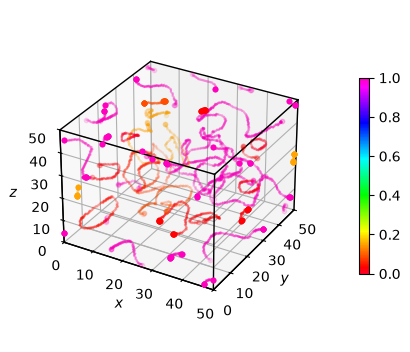

10.43981824198272


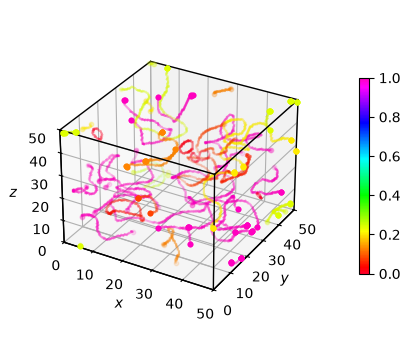

12.59387407603208


In [5]:
def makeplot2(n,show=False,save=True):
    if save and os.path.exists(filebase+'animation2/%04d.png'%(n)):
        return
    file=open(filebase+'states.dat','rb')
    file.seek((n0+n)*8*2*Ns[0]*Ns[1]*Ns[2])
    dat=file.read(8*2*Ns[0]*Ns[1]*Ns[2])
    ys=np.array(struct.unpack('%id'%(2*Ns[0]*Ns[1]*Ns[2]),dat)).reshape([2]+Ns.tolist())
    file.close()

    fig = plt.figure(figsize=(4,4), layout='constrained')

    ax = fig.add_subplot(1,1,1, projection='3d')
    tmp_planes = ax.zaxis._PLANES
    ax.zaxis._PLANES = (tmp_planes[2], tmp_planes[3], tmp_planes[0], tmp_planes[1], tmp_planes[4], tmp_planes[5])
    th=np.atan2(ys[1],ys[0])+np.pi
    lines=findlines(th)
    plotlines(lines, ax, plt.get_cmap('gist_rainbow'))
    # ax.set_box_aspect(aspect=None, zoom=0.8) 
    fig.colorbar(ScalarMappable(norm=Normalize(vmin=0, vmax=1), cmap=plt.get_cmap('gist_rainbow')),ax=ax,location='right', shrink=0.5)
    ax.set_box_aspect(aspect=None, zoom=0.8) 

    if save:
        plt.savefig(filebase+'animation2/%04d.png'%(n),bbox_inches="tight", pad_inches=0.1)
    if show:
        plt.show()
    plt.close(fig)

start=timeit.default_timer()
makeplot2(0,show=True,save=False)
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
makeplot2(nt-1,show=True,save=False)
stop=timeit.default_timer()
print(stop-start)

In [6]:
if not os.path.exists(filebase+'animation2'):
    os.mkdir(filebase+'animation2')
else:
    os.system('rm %sanimation2/*.png'%(filebase))

print(nt)
start=timeit.default_timer()
pool=Pool(16,maxtasksperchild=1) 
pool.map(makeplot2, range(nt))
pool.close()
stop=timeit.default_timer()
print("plot time: ", stop-start)

os.system('ffmpeg -y -r 30 -i %sanimation2/'%(filebase)+'%04d.png'+ ' -c:v h264 -vf "pad=ceil(iw/2)*2:ceil(ih/2)*2,format=yuv420p" %sanimation2.mp4'%(filebase))
display(Video('%sanimation2.mp4'%(filebase)))


1000
plot time:  883.6145011490444


ffmpeg version 8.0.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (GCC)
  configuration: --prefix=/nfs/home/znicolao/.conda/envs/my_env --cc=/home/task_177679469598008/croot/ffmpeg_1776795393650/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/task_177679469598008/croot/ffmpeg_1776795393650/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/task_177679469598008/croot/ffmpeg_1776795393650/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/task_177679469598008/croot/ffmpeg_1776795393650/_build_env/bin/x86_64-conda-linux-gnu-ar --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --enable-libmp3lame --enable-libaom --enable-libsvtav1 --enable-libxml2 --enable-pic --enable-shared --enable-version3 --enable-zlib --enable-libvorbis --enable-libopus --enable-libwebp --enable-libshaderc --disable-ffplay --disable-static --disable-gpl --disable-doc 

Correlate the lines between timesteps

In [4]:
def savelines(n):
    file=open(filebase+'states.dat','rb')
    file.seek((n0+n)*8*2*Ns[0]*Ns[1]*Ns[2])
    dat=file.read(8*2*Ns[0]*Ns[1]*Ns[2])
    ys=np.array(struct.unpack('%id'%(2*Ns[0]*Ns[1]*Ns[2]),dat)).reshape([2]+Ns.tolist())
    file.close()
    th=np.atan2(ys[1],ys[0])+np.pi
    return findlines(th)
    
start=timeit.default_timer()
pool=Pool(16,maxtasksperchild=1) 
lines=pool.map(savelines, range(nt))
pool.close()
stop=timeit.default_timer()
print("lines time: ", stop-start)

flat=[]
for i in range(nt):
    for l in lines[i]:
        flat+=l.ravel().tolist()
len(flat)*8/2**30

lines time:  102.43673333898187


0.5207355916500092

In [62]:
#correlate the ids across adjacent timesteps
def correlate(n):
    ids=np.arange(len(lines[n]))
    nextid=len(lines[n-1])
    for i in range(len(lines[n])):
        mindist=np.inf
        minind=0
        minlen=0
        for j in range(len(lines[n-1])):
            dist=np.round(np.min(np.linalg.norm(lines[n][i][:,np.newaxis]/(Ls/(Ns-1))-lines[n-1][j][np.newaxis,:]/(Ls/(Ns-1)),ord=np.inf,axis=-1)))
            if dist<=mindist:
                if dist<mindist or len(lines[n-1][j])>minlen:
                    minind=j
                    mindist=dist
                    minlen=len(lines[n-1][j])
                
        if mindist>3:
            ids[i]=nextid
            nextid=nextid+1
        else:
            ids[i]=np.arange(len(lines[n-1]))[minind]
    return ids
        
start=timeit.default_timer()
pool=Pool(16,maxtasksperchild=1) 
ids=[np.arange(len(lines[0]))]+pool.map(correlate, range(1,nt))
pool.close()


stop=timeit.default_timer()
print("correlate time: ", stop-start)


correlate time:  802.9971827140544


In [151]:
#we haven't differentiated between a line collapse and two lines colliding here yet

In [157]:
ids[:10]

[array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  0,  8,  9, 10, 11]),
 array([ 0,  1,  2,  3,  4,  5,  6,  0,  7, 13, 14,  8,  9, 10, 11, 12]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 16, 12, 13, 14, 15]),
 array([ 0,  1,  2,  4,  3,  5,  6,  7,  8,  9, 12, 13, 14, 15, 16]),
 array([ 0,  1,  2,  4,  3, 15,  5,  6,  7,  9,  8, 10, 11, 12, 13, 14]),
 array([ 0,  1,  2,  4,  3,  5,  6,  7,  8,  9, 10, 11, 12, 13, 16, 14, 15]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 11,  8, 12, 13, 15, 16])]

In [156]:
n=7
for c in ids[n]:
    print(c,np.any(c==ids[n-1]))

0 True
1 True
2 True
4 True
3 True
15 True
5 True
6 True
7 True
9 True
8 True
10 False
11 False
12 True
13 True
14 True


In [131]:
#propogate the ids across the timesteps
nextid=len(ids[0])
newids=[ids[0].copy()]
for n in range(1,nt):
    newids=newids+[ids[n].copy()]

    for c in range(len(newids[n])):
        parents=[]
        
        if newids[n][c]<len(newids[n-1]):
            parents=np.where(newids[n-1][newids[n][c]]==newids[n-1])[0]
            newids[n][c]=newids[n-1][parents[0]]
        else:
            print('birth', nextid)
            newids[n][c]=nextid
            nextid=nextid+1
            
    #relabel children that share a single parent id with the next ids
    uniq,count=np.unique(newids[n],return_counts=True)
    for i in np.where(count>1)[0]:
        for c in (np.where(newids[n]==uniq[i])[0]):
            print('budding',n,uniq[i],nextid)
            newids[n][c]=nextid
            nextid=nextid+1

    for c in range(len(newids[n-1])):
        children=[]
        children=np.where(newids[n-1][c]==newids[n])[0]
        #one parent, propogate id
        if len(children)==0:
            print('death', n, newids[n-1][c])

budding 3 0 12
budding 3 0 13
death 3 0
birth 14
birth 15
budding 4 12 16
budding 4 12 17
death 4 12
birth 18
death 6 15
death 6 13
birth 19
birth 20
budding 9 17 21
budding 9 17 22
death 9 17
death 9 7
death 9 20
death 10 22
birth 23
birth 24
death 11 4
death 12 23
death 13 5
death 13 11
birth 25
birth 26
birth 27
death 14 8
birth 28
birth 29
birth 30
death 20 25
death 20 10
death 21 1
death 21 28
death 22 24
death 23 26
death 24 29
birth 31
death 26 30
budding 27 21 32
budding 27 21 33
death 27 14
death 27 21
death 27 18
budding 29 2 34
budding 29 2 35
budding 29 16 36
budding 29 16 37
death 29 16
death 29 2
death 29 31
death 30 3
budding 32 35 38
budding 32 35 39
death 32 19
death 32 35
death 32 33
birth 40
budding 33 32 41
budding 33 32 42
budding 33 34 43
budding 33 34 44
death 33 34
death 33 32
birth 45
budding 37 36 46
budding 37 36 47
death 37 36
budding 39 44 48
budding 39 44 49
death 39 45
death 39 44
birth 50
birth 51
death 43 47
death 46 39
birth 52
budding 47 37 53
budding

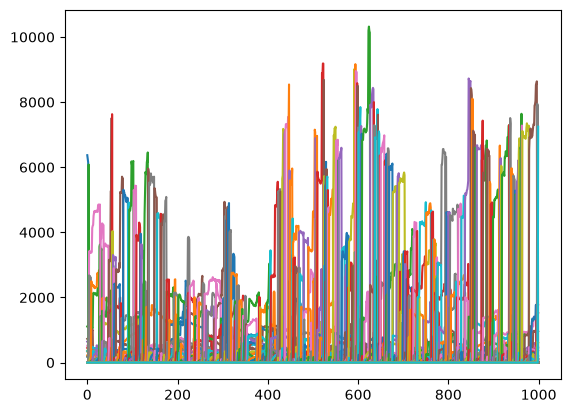

In [132]:
for i in range(np.max(newids[-1])):
    plt.plot([np.sum([len(lines[n][c]) for c in np.where(newids[n]==i)[0]]) for n in range(nt)],label='$%i$'%(i))
plt.show()

In [105]:
def plotlines2(lines, ids, ax):
    for i in range(len(lines)):
        c=colors[np.mod(ids[i],len(colors))]
        for line in lines[i]:
            if np.linalg.norm(line[0]-line[1],ord=np.inf)<np.min(Ls)/2:
                alpha=0.1*np.linalg.norm(([0,Ls[1],0]-line[0])/Ls,ord=np.inf)
                ax.plot(*line.T,lw=1.5, marker=None, c=c, alpha=alpha)
            else:
                if (line[0][0]==0 or line[0][1]==Ls[1] or line[0][2]==0) and not (line[1][0]==0 or line[1][1]==Ls[1] or line[1][2]==0):
                    ax.scatter(*line[0],s=10,color=c,alpha=0.25)
                if (line[0][0]==Ls[0] or line[0][1]==0 or line[0][2]==Ls[2]) and not (line[1][0]==Ls[0] or line[1][1]==0 or line[1][2]==Ls[2]):
                    ax.scatter(*line[0],s=10,color=c,alpha=1.0)
                if (line[1][0]==0 or line[1][1]==Ls[1] or line[1][2]==0) and not (line[0][0]==0 or line[0][1]==Ls[1] or line[0][2]==0):
                    ax.scatter(*line[1],s=10,color=c,alpha=0.25)
                if (line[1][0]==Ls[0] or line[1][1]==0 or line[1][2]==Ls[2]) and not (line[0][0]==Ls[0] or line[0][1]==0 or line[0][2]==Ls[2]):
                    ax.scatter(*line[1],s=10,color=c,alpha=1.0)
    
    ax.plot([Ls[0],Ls[0]],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[0,0],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[0,0],[0,0], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[0,0], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,0],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[Ls[1],Ls[1]],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[Ls[1],Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,0],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    
    ax.set_xlim(0,Ls[0])
    ax.set_ylim(0,Ls[1])
    ax.set_zlim(0,Ls[1])
    
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_zlabel('$z$')

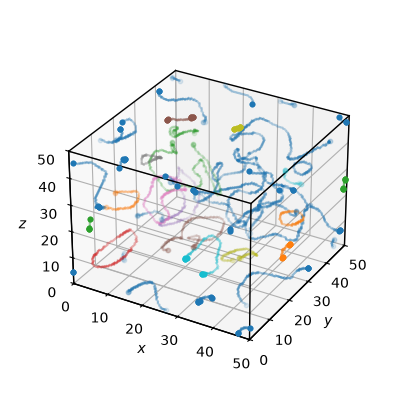

14.073507639928721


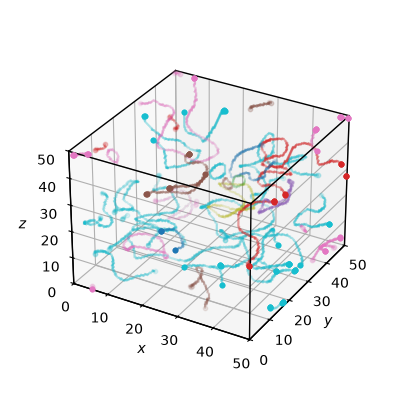

15.329807832022198


In [106]:
def makeplot3(n,show=False,save=True):
    if save and os.path.exists(filebase+'animation3/%04d.png'%(n)):
        return
    file=open(filebase+'states.dat','rb')
    file.seek((n0+n)*8*2*Ns[0]*Ns[1]*Ns[2])
    dat=file.read(8*2*Ns[0]*Ns[1]*Ns[2])
    ys=np.array(struct.unpack('%id'%(2*Ns[0]*Ns[1]*Ns[2]),dat)).reshape([2]+Ns.tolist())
    file.close()

    fig = plt.figure(figsize=(4,4), layout='constrained')
    
    ax = fig.add_subplot(1,1,1, projection='3d')
    tmp_planes = ax.zaxis._PLANES
    ax.zaxis._PLANES = (tmp_planes[2], tmp_planes[3], tmp_planes[0], tmp_planes[1], tmp_planes[4], tmp_planes[5])
    th=np.atan2(ys[1],ys[0])+np.pi
    lines=findlines(th)
    plotlines2(lines, newids[n], ax)
    ax.set_box_aspect(aspect=None, zoom=0.8) 

    if save:
        plt.savefig(filebase+'animation3/%04d.png'%(n),bbox_inches="tight", pad_inches=0.1)
    if show:
        plt.show()
    plt.close(fig)

start=timeit.default_timer()
makeplot3(0,show=True,save=False)
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
makeplot3(nt-1,show=True,save=False)
stop=timeit.default_timer()
print(stop-start)

In [107]:
if not os.path.exists(filebase+'animation3'):
    os.mkdir(filebase+'animation3')
else:
    os.system('rm %sanimation3/*.png'%(filebase))

print(nt)
start=timeit.default_timer()
pool=Pool(16,maxtasksperchild=1) 
pool.map(makeplot3, range(nt))
pool.close()
stop=timeit.default_timer()
print("plot time: ", stop-start)

os.system('ffmpeg -y -r 30 -i %sanimation3/'%(filebase)+'%04d.png'+ ' -c:v h264 -vf "pad=ceil(iw/2)*2:ceil(ih/2)*2,format=yuv420p" %sanimation3.mp4'%(filebase))
display(Video('%sanimation3.mp4'%(filebase)))


1000
plot time:  910.0312130870298


ffmpeg version 8.0.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (GCC)
  configuration: --prefix=/nfs/home/znicolao/.conda/envs/my_env --cc=/home/task_177679469598008/croot/ffmpeg_1776795393650/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/task_177679469598008/croot/ffmpeg_1776795393650/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/task_177679469598008/croot/ffmpeg_1776795393650/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/task_177679469598008/croot/ffmpeg_1776795393650/_build_env/bin/x86_64-conda-linux-gnu-ar --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --enable-libmp3lame --enable-libaom --enable-libsvtav1 --enable-libxml2 --enable-pic --enable-shared --enable-version3 --enable-zlib --enable-libvorbis --enable-libopus --enable-libwebp --enable-libshaderc --disable-ffplay --disable-static --disable-gpl --disable-doc 